
## Title: Semantic Network

# Objectives
- To understand what Semantic Networks are in Natural Language Processing.

-To learn how to take text that is not organized and turn it into knowledge that is organized.

-To study some Natural Language Processing techniques like POS tagging and Named Entity Recognition and vector embeddings.

-To understand how knowledge triples show the relationships between entities in Semantic Networks.

-To explore how Semantic Networks can be used to make recommendations in recommendation systems.

This is one of the uses of Semantic Networks, in Natural Language Processing.
# Theory
Semantic Network is a graph that shows knowledge. It has concepts or entities as points and the connections between them as lines.

This helps organize information in a way. It makes it easy to find connections between concepts.

Semantic networks are used in Natural Language Processing, knowledge graphs, search engines and recommendation systems.

### Part-of-Speech Tagging

Part-of-Speech Tagging is one of the steps in Natural Language Processing.

The system breaks down text into words.

Then it gives each word a category like noun, verb or adjective.

For example:

The sentence is "Students study NLP."

The tags are:

* Students. Noun

* study. Verb

* NLP. Name

This helps find the sentence structure.

It gives information for later tasks.

### Named Entity Recognition

Named Entity Recognition finds things in text.

It puts them into categories.

The categories are:

* Person

* Organization

* Location

* Date

* Product

For example:

The sentence is "John works at OpenAI in San Francisco."

The output is:

* John. Person

* OpenAI. Organization

* San Francisco. Location

This turns text into structured information.

### Vector Embeddings

Vector Embeddings turn text into numbers.

Computers can understand these numbers.

Each word becomes a list of numbers.

This list shows what the word means.

For example:

The word is "Student".

The embedding is:

[0.24, -0.71, 0.52... 0.13]

Words with meanings have similar numbers.

They are close together in the number space.

This helps machines understand how words are related.

### Knowledge Triples

Knowledge Triples show relationships between things.

They have three parts:

* Subject

* Predicate

* Object

For example:

* (Student, studies, NLP)

* (John, works_at, OpenAI)

These triples are a way to show relationships.

Many triples can be connected to form a knowledge graph.

Semantic Network System:

A semantic network uses Part-of-Speech tagging, Named Entity Recognition, embeddings and knowledge triples.

It makes a graph of knowledge.

It helps understand relationships, between concepts.

It can be used in recommendation systems.

# CODE


In [7]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# -----------------------------
# 1. Synthetic Research Dataset
# -----------------------------
paper_titles = [
    ("ResNet-3D: Residual Grids for Spatial Volumetric Analysis", "CV", "CNNs", "Dr_Y_LeCun"),
    ("ViT-Scale: Scaling Vision Transformers for Dense Prediction", "CV", "Transformers", "Dr_A_Vaswani"),
    ("SimCLR-V3: Contrastive Frameworks for Self-Supervised Vision", "CV", "CL", "Dr_G_Hinton"),
    ("Masked Autoencoders Are Scalable Vision Visualizers", "CV", "Transformers", "Dr_Y_LeCun"),
    ("NeRF-Graph: Neural Radiance Fields on Graph Topologies", "CV", "GNNs", "Dr_J_Leskovec"),
    ("Real-Time Semantic Segmentation via Dilated Spatial Kernels", "CV", "CNNs", "Dr_Y_LeCun"),

    ("BERT-Large: Pre-training of Deep Bidirectional Transformers", "NLP", "Transformers", "Dr_A_Vaswani"),
    ("GPT-Next: Autoregressive Language Modeling at Scale", "NLP", "Transformers", "Dr_A_Vaswani"),
    ("Contrastive Sentence Embeddings via Semantic Invariance", "NLP", "CL", "Dr_Y_Bengio"),
    ("Long-Short Sequence Parsing via Linear Attention Windows", "NLP", "Transformers", "Dr_A_Vaswani"),
    ("Text-Graph Recurrent Transformers for Structured Document Analysis", "NLP", "GNNs", "Dr_J_Leskovec"),

    ("GCN-V2: Scalable Graph Convolutional Networks via Node Sampling", "Graph_AI", "GNNs", "Dr_J_Leskovec"),
    ("Graph Attention Networks with Multi-Head Structural Alignment", "Graph_AI", "Transformers", "Dr_A_Vaswani"),
    ("Self-Supervised Graph Contrastive Learning via Subgraph Masking", "Graph_AI", "CL", "Dr_Y_Bengio"),
    ("Temporal Graph Networks for Dynamic Relational Interaction Stream", "Graph_AI", "GNNs", "Dr_J_Leskovec"),
]

# -----------------------------
# 2. Convert papers → text docs
# -----------------------------
paper_texts = [
    f"{title} {domain} {method} {author}"
    for title, domain, method, author in paper_titles
]

# -----------------------------
# 3. TF-IDF + Cosine Similarity
# -----------------------------
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(paper_texts)

cosine_sim = cosine_similarity(tfidf_matrix)

# -----------------------------
# 4. Jaccard Similarity
# -----------------------------
def jaccard_similarity(a, b):
    set_a = set(a.lower().split())
    set_b = set(b.lower().split())

    if not set_a and not set_b:
        return 0

    return len(set_a & set_b) / len(set_a | set_b)

# -----------------------------
# 5. Recommendation Function
# -----------------------------
def recommend(paper_index, top_k=5):
    print("\nRecommendations for:")
    print(paper_titles[paper_index][0])

    cosine_scores = []
    jaccard_scores = []

    for i in range(len(paper_titles)):
        if i == paper_index:
            continue

        cos_score = cosine_sim[paper_index][i]
        jac_score = jaccard_similarity(
            paper_texts[paper_index],
            paper_texts[i]
        )

        cosine_scores.append((i, cos_score))
        jaccard_scores.append((i, jac_score))

    # sort each list independently by its own score
    cosine_scores.sort(key=lambda x: x[1], reverse=True)
    jaccard_scores.sort(key=lambda x: x[1], reverse=True)

    # ---- Cosine Similarity Results ----
    print("-" * 70)
    print("Top recommendations by Cosine Similarity (TF-IDF):")
    print("-" * 70)
    for i, score in cosine_scores[:top_k]:
        print(f"{paper_titles[i][0]} | Score: {score:.3f}")

    # ---- Jaccard Similarity Results ----
    print("-" * 70)
    print("Top recommendations by Jaccard Similarity:")
    print("-" * 70)
    for i, score in jaccard_scores[:top_k]:
        print(f"{paper_titles[i][0]} | Score: {score:.3f}")

# -----------------------------
# 6. Run example
# -----------------------------
recommend(0)


Recommendations for:
ResNet-3D: Residual Grids for Spatial Volumetric Analysis
----------------------------------------------------------------------
Top recommendations by Cosine Similarity (TF-IDF):
----------------------------------------------------------------------
Real-Time Semantic Segmentation via Dilated Spatial Kernels | Score: 0.285
Text-Graph Recurrent Transformers for Structured Document Analysis | Score: 0.148
Masked Autoencoders Are Scalable Vision Visualizers | Score: 0.126
ViT-Scale: Scaling Vision Transformers for Dense Prediction | Score: 0.094
SimCLR-V3: Contrastive Frameworks for Self-Supervised Vision | Score: 0.092
----------------------------------------------------------------------
Top recommendations by Jaccard Similarity:
----------------------------------------------------------------------
Real-Time Semantic Segmentation via Dilated Spatial Kernels | Score: 0.250
ViT-Scale: Scaling Vision Transformers for Dense Prediction | Score: 0.118
SimCLR-V3: Contra

## OUTPUT
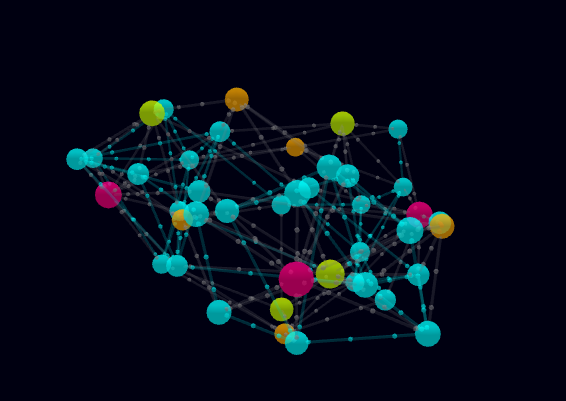

# DISCUSSION

The project shows how graph analytics and natural language processing can work together for knowledge management.

The first module creates a literature ecosystem with authors, domains, methodologies and research papers. This ecosystem is in the form of a graph that includes relationships and citation links which makes it look like real-world scholarly communication networks.

* A key benefit of the citation generation approach is that it is designed to be sensitive to the research domain.

Papers tend to cite works from the research area but they also occasionally cite works from other areas.

This leads to clustering behavior and helps different research communities connect with each other within the network.

The interactive 3D visualization helps users understand these relationships better.

They can look at entities follow citation pathways and see how different research communities emerge through the graphs structure.

The second module adds a recommendation mechanism based on how similar textsre

Similarly recommendations are based on metadata and titles not on full paper abstracts or complete texts.

Despite these limitations the framework that was implemented successfully demonstrates the principles of modern research discovery systems, such, as citation analysis platforms, academic search engines and knowledge graph-based recommendation engines.



# CONCLUSION

This project successfully developed an integrated academic literature analysis framework consisting of a Knowledge Graph-based Citation Network and a Content-Based Research Paper Recommendation System.
The knowledge graph module modeled scholarly entities such as papers, authors, methodologies, and research domains as interconnected nodes linked through semantic and citation relationships. The resulting network enabled visualization of academic structures and facilitated exploration of research connectivity.

The recommendation module employed TF-IDF vectorization, cosine similarity, and Jaccard similarity to identify semantically related research papers. By combining these similarity measures through a hybrid scoring strategy, the system generated meaningful recommendations that reflected both conceptual and lexical relationships among publications.
The integration of graph-based knowledge representation and natural language processing techniques demonstrates how modern intelligent research systems can support literature discovery, academic analytics, and knowledge exploration. The project provides a practical foundation for developing advanced scholarly search engines, citation analysis tools, recommendation platforms, and graph-based AI applications.

Future enhancements may include real-world publication datasets, graph neural network models, citation weighting mechanisms, temporal analysis, abstract-level semantic embeddings, and machine learning-based recommendation algorithms. Such improvements would increase both the realism and analytical capabilities of the framework, making it suitable for large-scale academic knowledge management systems.




